# Clustering y Reducción de Dimensionalidad

**Caso de Estudio:** Ecommerce Customer Dataset
**Asignatura:** MLY1101 — Machine Learning
**Actividad 2.3.2 — Guía de Clustering y Reducción de Dimensionalidad**

---

## Descripción

Las campañas masivas genéricas ya no son rentables: el banco necesita personalizar sus planes de
fidelización. El objetivo de este notebook es **agrupar a los clientes según su comportamiento
financiero**, sin usar ninguna etiqueta previa (aprendizaje no supervisado), para descubrir
segmentos que permitan diseñar campañas específicas y éticas.

Sigue los cuatro pasos de la guía:

1. Carga de datos y preparación (selección de variables y escalado).
2. Elección del número de clústeres con el método del codo.
3. Entrenamiento de K-Means y visualización de los grupos con PCA.
4. Interpretación del perfil de negocio de cada clúster.

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. Las versiones exactas están fijadas en
[`requirements.txt`](../requirements.txt):

- pandas 2.3.3
- numpy 2.0.2
- matplotlib 3.9.4
- scikit-learn 1.6.1

# Importación de librerías

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('bmh')

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

# Advertencia espuria de numpy con la librería de cálculo de macOS; no afecta los resultados.
warnings.filterwarnings('ignore', message='.*encountered in matmul', category=RuntimeWarning)

os.makedirs('../images', exist_ok=True)
SEMILLA = 42
N_INICIOS = 300   # inicializaciones de K-Means; el Paso 3 muestra por qué hacen falta tantas

# Paso 1 — Carga de datos y preparación

Se seleccionan **solo las variables numéricas que definen el perfil comercial** del cliente:

- **Incluidas:** CreditScore, Age, Tenure, Balance, NumOfProducts y EstimatedSalary.
- **Excluidas:**
  - RowNumber, CustomerId y Surname: identificadores, no describen al cliente.
  - Geography y Gender: son categorías, no medidas numéricas. K-Means agrupa por distancia, y
    una distancia entre "Francia" y "España" no tiene sentido.
  - HasCrCard e IsActiveMember: binarias (0/1). Con solo dos valores posibles dominarían la
    distancia y partirían a los clientes en "sí/no" en vez de por su perfil.
  - Exited: es el resultado que se quiere entender, no una característica del perfil. Se usa
    después, en el Paso 4, para ver cuánto abandona cada grupo.

In [2]:
df = pd.read_csv('../data/ecommerce_customer_data.csv')

variables_perfil = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
X = df[variables_perfil]
X.describe().round(1)

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,650.5,38.9,5.0,76485.9,1.5,100090.2
std,96.7,10.5,2.9,62397.4,0.6,57510.5
min,350.0,18.0,0.0,0.0,1.0,11.6
25%,584.0,32.0,3.0,0.0,1.0,51002.1
50%,652.0,37.0,5.0,97198.5,1.0,100193.9
75%,718.0,44.0,7.0,127644.2,2.0,149388.2
max,850.0,92.0,10.0,250898.1,4.0,199992.5


Las escalas son muy distintas: Balance llega a 250.898 y EstimatedSalary a casi 200.000, mientras
que NumOfProducts va de 1 a 4. K-Means agrupa por distancia, así que sin escalar, una diferencia
de 1.000 en el saldo pesaría mucho más que tener 3 productos en vez de 1. Por eso se aplica
**StandardScaler**, que deja cada variable con media 0 y desviación 1: todas pesan lo mismo.

In [3]:
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

pd.DataFrame(X_escalado, columns=variables_perfil).describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,-0.00,0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-3.11,-1.99,-1.73,-1.23,-0.91,-1.74
25%,-0.69,-0.66,-0.70,-1.23,-0.91,-0.85
50%,0.02,-0.18,-0.00,0.33,-0.91,0.00
75%,0.70,0.48,0.69,0.82,0.81,0.86
max,2.06,5.06,1.72,2.80,4.25,1.74


# Paso 2 — Número óptimo de clústeres (método del codo)

Se entrena K-Means con K = 1 hasta K = 10 y se guarda la **inercia** de cada uno: la suma de las
distancias al cuadrado de cada cliente al centro de su grupo. Mientras más grupos, menor la
inercia (con 10.000 grupos sería 0), así que no se busca el mínimo, sino el **codo**: el punto a
partir del cual agregar un grupo más ya casi no la reduce.

Cada K se entrena con 300 inicializaciones distintas (n_init) y se queda con la de menor inercia.
Con menos inicializaciones, K-Means puede quedarse en una solución peor; el Paso 3 lo muestra.

Como complemento se calcula el **coeficiente de Silhouette** (desde K = 2), que mide qué tan
separados están los grupos entre sí: va de -1 a 1, y mientras más alto, más claros son los grupos.

In [4]:
rango_k = range(1, 11)
inercias = []
silhouettes = []
for k in rango_k:
    kmeans = KMeans(n_clusters=k, n_init=N_INICIOS, random_state=SEMILLA).fit(X_escalado)
    inercias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_escalado, kmeans.labels_) if k > 1 else np.nan)

resultados_k = pd.DataFrame({'inercia': inercias, 'silhouette': silhouettes}, index=rango_k)
resultados_k['reduccion_inercia'] = -resultados_k['inercia'].diff()
resultados_k.round(3)

,inercia,silhouette,reduccion_inercia
1,60000.000,NaN,NaN
2,49855.482,0.179,10144.518
3,44998.013,0.166,4857.469
4,41017.732,0.170,3980.281
5,38090.025,0.160,2927.707
6,35611.754,0.152,2478.271
7,33695.742,0.147,1916.012
8,32085.768,0.147,1609.974
9,30586.703,0.147,1499.065
10,29298.525,0.149,1288.178


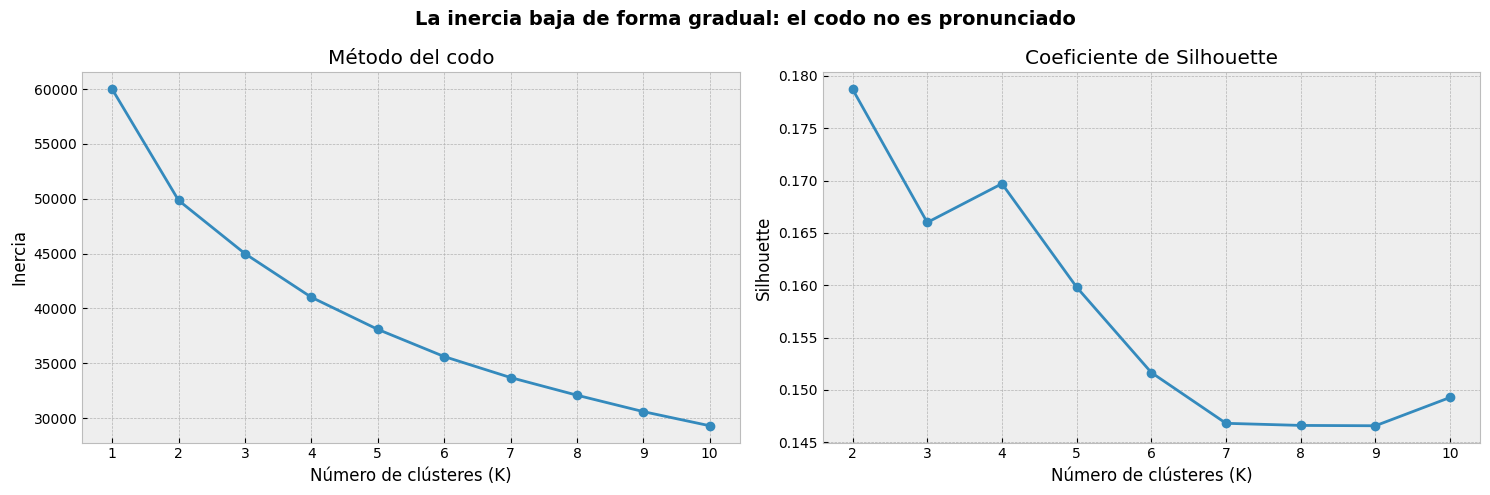

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(list(rango_k), inercias, marker='o')
axes[0].set_title('Método del codo')
axes[0].set_xlabel('Número de clústeres (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_xticks(list(rango_k))

axes[1].plot(list(rango_k)[1:], silhouettes[1:], marker='o')
axes[1].set_title('Coeficiente de Silhouette')
axes[1].set_xlabel('Número de clústeres (K)')
axes[1].set_ylabel('Silhouette')
axes[1].set_xticks(list(rango_k)[1:])

plt.suptitle('La inercia baja de forma gradual: el codo no es pronunciado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/clustering_codo.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ¿Qué grupos forma K = 3? Sirve para comparar con K = 4 en la justificación
kmeans_3 = KMeans(n_clusters=3, n_init=N_INICIOS, random_state=SEMILLA).fit(X_escalado)
X.groupby(kmeans_3.labels_)[['Age', 'Balance', 'NumOfProducts']].mean().round(1).rename_axis('cluster (K = 3)')

,Age,Balance,NumOfProducts
cluster (K = 3),,,
0,38.4,725.5,1.8
1,39.5,120118.5,1.0
2,38.8,120529.4,2.1


**Pregunta: ¿en qué valor de K se aprecia el codo? Justifica la elección.**

La inercia no muestra un codo marcado, sino una curva que baja de forma gradual. La mayor caída
está al pasar de K = 1 a K = 2 (-10.145); después la reducción se va achicando poco a poco
(-4.857 al pasar a K = 3, -3.980 a K = 4, -2.928 a K = 5, y menos de -2.500 desde ahí). Visualmente,
la curvatura se suaviza entre **K = 3 y K = 4**: a partir de K = 4, cada grupo adicional reduce la
inercia bastante menos.

Se elige **K = 4**, por tres razones:

- **Codo:** es el último valor antes de que la reducción de inercia baje de ~4.000 a ~3.000 y siga
  achicándose.
- **Silhouette:** K = 2 tiene el valor más alto (0,179), pero solo separa a los clientes con y sin
  saldo, algo que ya se sabía desde el EDA. Entre K = 3 y K = 10, el más alto es K = 4 (0,170,
  contra 0,147 a 0,166 del resto).
- **Utilidad para el negocio:** con K = 3 (tabla de arriba), los grupos se separan solo por el saldo
  y la cantidad de productos, y los tres tienen una edad promedio de 38 a 40 años. Con K = 4 aparece
  además un grupo de clientes mayores, una etapa de vida distinta que justifica campañas propias.

La elección usa solo las variables del agrupamiento: el abandono (Exited) no se usa para elegir K.
Se mira recién en el Paso 4, para describir a los grupos ya formados.

**Advertencia:** todos los Silhouette son bajos (menores a 0,2). Los clientes no forman grupos
naturales muy separados, sino un continuo; los clústeres son una forma útil de dividirlo en
segmentos, no grupos "reales" con límites claros.

# Paso 3 — Entrenamiento final de K-Means y visualización con PCA

In [7]:
K_OPTIMO = 4

kmeans = KMeans(n_clusters=K_OPTIMO, n_init=N_INICIOS, random_state=SEMILLA)
df['cluster'] = kmeans.fit_predict(X_escalado)

df['cluster'].value_counts().sort_index()

cluster
0    1991
1    1305
2    3233
3    3471
Name: count, dtype: int64

**¿El resultado depende de la semilla?** K-Means parte de centros iniciales al azar y mejora la
solución paso a paso, por lo que puede quedarse en una solución peor que la mejor posible (un
*mínimo local*). Para comprobar si eso ocurre, se entrena K-Means con K = 4 y cinco semillas
distintas, primero con 10 inicializaciones (el valor que se suele usar) y luego con 300. Cada
resultado se compara con el modelo final usando el **índice de Rand ajustado (ARI)**: 1 significa
que agrupa a los clientes exactamente igual, y 0, que la coincidencia no es mayor que la de una
agrupación al azar.

In [8]:
filas = []
for n_inicios in [10, N_INICIOS]:
    for semilla in range(5):
        modelo = KMeans(n_clusters=K_OPTIMO, n_init=n_inicios, random_state=semilla).fit(X_escalado)
        filas.append({
            'n_init':               n_inicios,
            'semilla':              semilla,
            'inercia':              modelo.inertia_,
            'ARI vs. modelo final': adjusted_rand_score(df['cluster'], modelo.labels_),
        })

print(f'Inercia del modelo final: {kmeans.inertia_:.1f}')
pd.DataFrame(filas).set_index(['n_init', 'semilla']).round(3)

Inercia del modelo final: 41017.7


inercia  ARI vs. modelo final
n_init semilla                                 
10     0        41017.759                 0.997
       1        41151.799                 0.439
       2        41149.956                 0.445
       3        41205.965                 0.463
       4        41017.706                 0.999
300    0        41017.656                 0.997
       1        41017.730                 0.999
       2        41017.699                 1.000
       3        41017.635                 0.996
       4        41017.706                 0.999

- Con **10 inicializaciones**, 3 de las 5 semillas terminan en agrupaciones distintas de la final
  (ARI de 0,44 a 0,46), con una inercia apenas mayor (41.150 a 41.206, contra 41.018: menos de un
  0,5% de diferencia). Para K = 4 hay varias formas casi igual de buenas de partir a los clientes, y
  con pocas inicializaciones K-Means se queda con cualquiera de ellas. En esas soluciones
  alternativas, los clientes con saldo se separan por antigüedad (semillas 1 y 2) o por salario
  (semilla 3), en vez de por la cantidad de productos.
- Con **300 inicializaciones**, las 5 semillas llegan a la misma agrupación (ARI de 0,996 o más) y
  a la menor inercia.

Por eso el modelo final usa 300 inicializaciones: los segmentos que se interpretan en el Paso 4 no
dependen de la semilla.

Para ver los grupos en un gráfico hay que pasar de 6 dimensiones (una por variable) a 2. **PCA**
(Análisis de Componentes Principales) crea dos nuevas variables, combinaciones de las originales,
que conservan la mayor cantidad posible de la variación de los datos.

Varianza explicada por cada componente: [0.219 0.169]
Varianza explicada total: 0.387


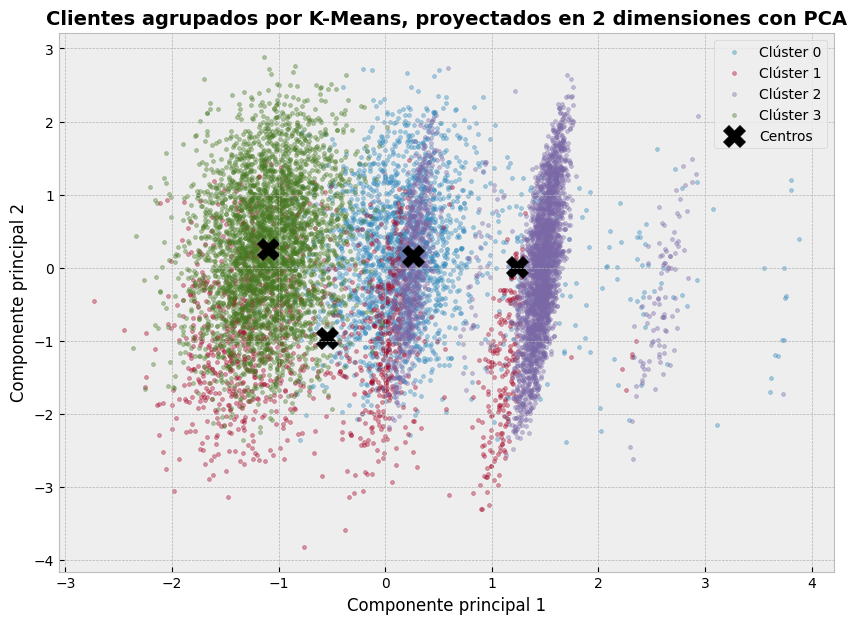

In [9]:
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_escalado)
centros_pca = pca.transform(kmeans.cluster_centers_)

print(f'Varianza explicada por cada componente: {np.round(pca.explained_variance_ratio_, 3)}')
print(f'Varianza explicada total: {pca.explained_variance_ratio_.sum():.3f}')

plt.figure(figsize=(10, 7))
for cluster in range(K_OPTIMO):
    mascara = df['cluster'] == cluster
    plt.scatter(componentes[mascara, 0], componentes[mascara, 1], s=8, alpha=0.4, label=f'Clúster {cluster}')
plt.scatter(centros_pca[:, 0], centros_pca[:, 1], s=250, c='black', marker='X', label='Centros')
plt.title('Clientes agrupados por K-Means, proyectados en 2 dimensiones con PCA', fontsize=14, fontweight='bold')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend()
plt.savefig('../images/clustering_pca.png', dpi=150, bbox_inches='tight')
plt.show()

Las dos componentes conservan el 38,7% de la variación de los datos (21,9% + 16,9%): el mapa es
una simplificación y es normal que los grupos se vean superpuestos en él.

- El **clúster sin saldo** queda separado a la derecha, en una franja vertical: el saldo es la
  variable que más distingue a los clientes.
- Los clientes con saldo se ordenan de izquierda a derecha según su cantidad de productos: los de
  **1 producto** a la izquierda y los de **2 o más** al centro.
- Los clientes **senior** se reparten a lo largo del eje horizontal, sobre todo en la parte
  inferior: se distinguen por la edad, que esta proyección muestra solo en parte.

Esto es coherente con el Silhouette bajo del Paso 2.

# Paso 4 — Interpretación del perfil de negocio

Se calcula el promedio de las variables originales (sin escalar) en cada clúster. Se agregan
tres columnas que no se usaron para agrupar, pero ayudan a describir cada grupo: el % de clientes
con saldo 0, el % de abandono (Exited) y el % de clientes activos.

In [10]:
perfil = df.groupby('cluster')[variables_perfil].mean()
perfil['pct_saldo_cero'] = df.groupby('cluster')['Balance'].apply(lambda s: (s == 0).mean() * 100)
perfil['pct_abandono'] = df.groupby('cluster')['Exited'].mean() * 100
perfil['pct_activos'] = df.groupby('cluster')['IsActiveMember'].mean() * 100
perfil['pct_1_producto'] = df.groupby('cluster')['NumOfProducts'].apply(lambda s: (s == 1).mean() * 100)
perfil['clientes'] = df['cluster'].value_counts()

# Nombre de cada clúster según su rasgo principal (así no depende del número que le asigne K-Means)
nombres = {}
nombres[perfil['Age'].idxmax()] = 'Senior'
nombres[perfil['pct_saldo_cero'].idxmax()] = 'Sin saldo'
assert len(nombres) == 2, 'El clúster de más edad es también el de más clientes sin saldo: revisar los nombres'
restantes = perfil.drop(index=list(nombres)).sort_values('NumOfProducts')
nombres[restantes.index[0]] = 'Con saldo, 1 producto'
nombres[restantes.index[1]] = 'Con saldo, 2+ productos'

perfil.index = [f'{c} - {nombres[c]}' for c in perfil.index]
perfil.round(1)

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,pct_saldo_cero,pct_abandono,pct_activos,pct_1_producto,clientes
"0 - Con saldo, 2+ productos",653.4,36.9,5.0,121155.2,2.1,103587.7,0.7,20.6,50.3,0.0,1991
1 - Senior,652.0,58.6,4.9,77133.9,1.3,94277.5,33.0,45.4,64.4,71.6,1305
2 - Sin saldo,648.8,35.6,5.1,890.8,1.8,99284.7,98.2,9.8,49.7,21.0,3233
"3 - Con saldo, 1 producto",650.0,35.8,5.0,121031.2,1.0,101019.8,0.0,20.7,49.1,100.0,3471


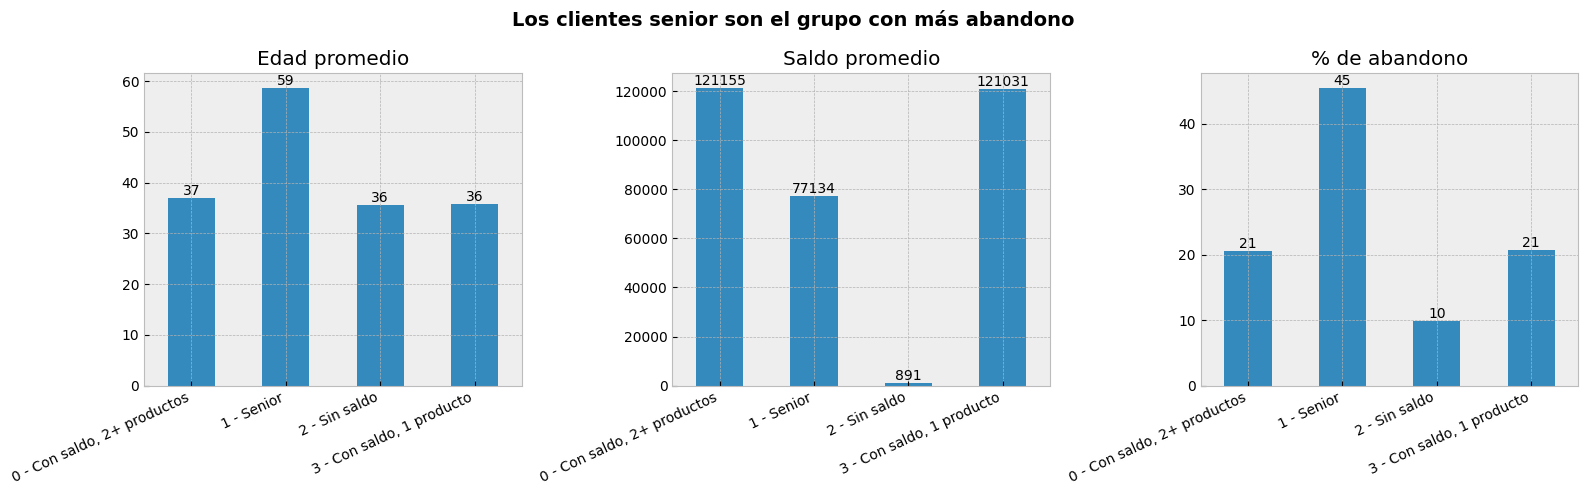

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (columna, titulo) in zip(axes, [('Age', 'Edad promedio'), ('Balance', 'Saldo promedio'),
                                          ('pct_abandono', '% de abandono')]):
    perfil[columna].plot(kind='bar', ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
    ax.bar_label(ax.containers[0], fmt='%.0f')
    ax.set_title(titulo)
plt.suptitle('Los clientes senior son el grupo con más abandono', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/clustering_perfiles.png', dpi=150, bbox_inches='tight')
plt.show()

**Identidad de los clústeres descubiertos:**

| Clúster | Perfil | Rasgos principales |
|---|---|---|
| **Con saldo, 1 producto** (3.471 clientes) | Clientes jóvenes con fondos y un solo producto | 36 años, saldo medio ~121.000 (ninguno con saldo 0) y todos con exactamente 1 producto. Abandono de 21%. |
| **Con saldo, 2+ productos** (1.991) | Clientes jóvenes con fondos y varios productos | 37 años, saldo medio ~121.000 (menos del 1% con saldo 0) y 2 o más productos. Abandono de 21%. |
| **Sin saldo** (3.233) | Clientes jóvenes sin fondos | 36 años, saldo medio ~900 (98% con saldo 0); la mayoría tiene 2 productos. El **abandono más bajo: 10%**. |
| **Senior** (1.305) | Clientes mayores, con saldo medio | Edad promedio 59 años, saldo medio ~77.100 y 33% sin saldo. Son los más activos (64%), pero tienen el **abandono más alto: 45%**. |

El puntaje crediticio, el salario estimado y la antigüedad son casi iguales en los cuatro grupos
(~649-653, ~94.000-104.000 y ~5 años): no definen ningún segmento. Lo que separa a los clientes es
la edad, el saldo y la cantidad de productos, las mismas variables que destacó el EDA (Secciones
4.2, 4.3 y 5.3), pero ahora descubiertas sin usar el abandono para agrupar.

In [12]:
# Composición por país de cada clúster (% de clientes)
por_pais = pd.crosstab(df['cluster'].map(lambda c: f'{c} - {nombres[c]}'), df['Geography'], normalize='index') * 100
por_pais.round(1)

Geography,France,Germany,Spain
cluster,,,
"0 - Con saldo, 2+ productos",31.8,52.6,15.6
1 - Senior,47.5,27.4,25.1
2 - Sin saldo,66.2,0.8,33.0
"3 - Con saldo, 1 producto",46.7,31.1,22.3


Los clústeres no usaron el país para agrupar, pero su composición no es pareja: el grupo **Sin
saldo** casi no tiene clientes alemanes (0,8%), y el de **Con saldo, 2+ productos** es mitad alemán
(52,6%), contra 27-31% en los otros dos. Las dos cosas son consecuencia de que ningún cliente de
Alemania tiene saldo 0 en esta muestra, un patrón que probablemente se debe a cómo se armó la
muestra (EDA, Sección 2.7). En Francia y España, la mayoría de los clientes con 2 productos no tiene
saldo (EDA, Sección 5.3), así que entre los clientes con saldo y varios productos predominan los
alemanes. Hay que tenerlo en cuenta: una campaña dirigida a ese clúster alcanzaría sobre todo a
clientes alemanes, por cómo se construyeron los datos y no por una decisión explícita.

# Desafío estratégico

**Si el banco lanzara un producto de inversión de alta gama y bajo riesgo, ¿a qué clúster
enfocarías éticamente la campaña y por qué?**

Al clúster **Con saldo, 1 producto**:

- **Tienen fondos para invertir:** saldo promedio de ~121.000 y ningún cliente con saldo 0. Un
  producto de alta gama requiere capital disponible, y ofrecérselo a quien lo tiene no compromete
  sus necesidades básicas.
- **Amplía la relación sin sobrecargarla:** hoy tienen un solo producto. En el EDA, los clientes con
  2 productos son los que menos abandonan (7,6%, contra 27,7% con 1 producto; Sección 4.2). Es una
  asociación, no una prueba de que sumar un producto retenga al cliente, pero indica que un segundo
  producto bien elegido es coherente con el perfil de los clientes más estables de la cartera.
- **Es el segmento más grande y el menos afectado por el sesgo de la muestra:** 3.471 clientes, con
  una proporción de alemanes (31%) cercana a la del total (25%).
- **Coherente con el bajo riesgo:** a clientes con fondos les conviene diversificar sin arriesgar su
  patrimonio.

**Qué no sería ético o prudente:**

- **Clúster Sin saldo:** empujar un producto de inversión a clientes que casi no tienen fondos
  podría llevarlos a endeudarse o a comprometer dinero que necesitan.
- **Clúster Senior como blanco principal:** tienen fondos y un producto de bajo riesgo podría
  convenirles, pero son el grupo con más abandono (45%). La tentación sería usar la inversión
  como "gancho" para retenerlos, y dirigir productos financieros a personas mayores por su edad
  exige especial cuidado para no aprovecharse de ellos. Si se les ofrece, debe ser con asesoría
  transparente y no como campaña agresiva.
- **Clúster Con saldo, 2+ productos como blanco masivo:** tiene los mismos fondos, pero ya tiene 2 o
  más productos. En el EDA, tener 3 productos se asocia a un abandono del 82,7%, y tener 4, al 100%
  (Sección 4.2). Esa relación podría deberse a cómo se registraron los datos (EDA, Sección 2.9),
  pero basta para no sumarles un tercer producto con una campaña masiva. Además, la mitad de este
  grupo es alemán por el sesgo de la muestra. Si se les ofrece, que sea de forma individual y
  asesorada.

Además, la segmentación no usa género ni país, lo que evita que la campaña discrimine
directamente por esas características; aun así, como se vio arriba, la composición por país de
los clústeres está influida por cómo se armó la muestra.

# Resumen

- Se agrupó a los 10.000 clientes con K-Means según seis variables numéricas de su perfil
  comercial, escaladas con StandardScaler para que todas pesen lo mismo.
- K-Means se entrenó con **300 inicializaciones**: con 10, el resultado para K = 4 dependía de la
  semilla (3 de 5 semillas daban agrupaciones distintas); con 300, todas llegan a la misma.
- El método del codo no mostró un codo marcado. Se eligió **K = 4** por la curvatura entre K = 3 y
  K = 4, porque es el mayor Silhouette entre K = 3 y K = 10 (0,170), y porque separa a los clientes
  mayores, sin usar el abandono para decidir. El Silhouette bajo (< 0,2) indica que los clientes
  forman un continuo más que grupos naturalmente separados.
- PCA en dos dimensiones conserva el 38,7% de la variación: solo el grupo sin saldo se ve
  claramente separado.
- Los cuatro segmentos son **Con saldo, 1 producto**, **Con saldo, 2+ productos**, **Sin saldo**
  (10% de abandono) y **Senior** (45% de abandono). La antigüedad, el salario y el puntaje
  crediticio no diferencian a ningún segmento.
- Para un producto de inversión de alta gama y bajo riesgo, el público éticamente adecuado es
  **Con saldo, 1 producto**: tienen fondos, el producto amplía una relación que hoy es de un solo
  producto, y es el segmento menos afectado por el sesgo de la muestra.